### Prof. Alfio Ferrara

# Codificare l'informazione

##  Metodologie informatiche nelle discipline umanistiche
##### A.A. 2026/2027


In [ ]:
%load_ext autoreload
%autoreload 2

## Il linguaggio segreto

Formate gruppi di tre. In ogni gruppo:

- una persona è l'**agente segreto**: deve comunicare in quale delle seguenti nazioni si trova, usando solo delle carte da gioco mostrate una alla volta — **Italia, Francia, Russia, Cina, Brasile, Egitto**;
- una persona è il **complice**: riceve le carte e ha davanti un foglio con le regole di decodifica concordate in anticipo con l'agente;
- una persona è l'**agente avversario**: riceve la stessa sequenza di carte del complice, ma non conosce le regole di decodifica.

Prima di iniziare, l'agente e il complice si accordano in segreto su un codice: una corrispondenza tra sequenze di carte e nazioni. L'obiettivo dell'agente è comunicare la nazione corretta al complice usando **il minor numero di carte possibile** — senza che l'avversario riesca a capire di quale nazione si tratti.

Provate prima usando come simboli i 4 semi delle carte (cuori, quadri, fiori, picche). Poi ripetete usando solo il colore della carta (rosso o nero).

## Un momento di riflessione

- Quante carte vi sono servite nella prima prova (4 semi)? E nella seconda (2 colori)?
- L'agente avversario è riuscito a capire la nazione, pur avendo ricevuto la stessa identica sequenza di carte del complice? Perché sì o perché no?
- Cosa vi dice questo sul rapporto tra "ricevere un messaggio" e "capire un messaggio"?
- Perché con un alfabeto più piccolo servono più carte per comunicare lo stesso numero di messaggi?
- Avanzavano combinazioni non usate, in una delle due prove (o in entrambe)? Quante?

## Verifichiamo con il calcolo

Proviamo a calcolare, per ciascun alfabeto, quante carte servono davvero per 6 messaggi, e quante combinazioni restano inutilizzate.

In [1]:
from nlp.coding import minimum_code_length, num_possible_codes

num_messages = 6

for alphabet_size, label in [(4, "4 semi"), (2, "2 colori")]:
    length = minimum_code_length(alphabet_size, num_messages)
    combinations = num_possible_codes(alphabet_size, length)
    print(f"Alfabeto: {label} ({alphabet_size} simboli)")
    print(f"  Lunghezza minima del codice: {length} carte")
    print(f"  Combinazioni disponibili: {combinations}")
    print(f"  Combinazioni inutilizzate: {combinations - num_messages}")
    print()

print("Cosa succede se proviamo con una carta in meno del necessario (2 colori, 2 carte)?")
print(f"  Combinazioni disponibili: {num_possible_codes(2, 2)} per {num_messages} messaggi -> non bastano!")

Alfabeto: 4 semi (4 simboli)
  Lunghezza minima del codice: 2 carte
  Combinazioni disponibili: 16
  Combinazioni inutilizzate: 10

Alfabeto: 2 colori (2 simboli)
  Lunghezza minima del codice: 3 carte
  Combinazioni disponibili: 8
  Combinazioni inutilizzate: 2

Cosa succede se proviamo con una carta in meno del necessario (2 colori, 2 carte)?
  Combinazioni disponibili: 4 per 6 messaggi -> non bastano!


## Dal caso concreto alla formula generale

La lunghezza minima di un codice, dato un alfabeto di B simboli e un insieme di N messaggi possibili da distinguere, è:

$$L = \lceil \log_B(N) \rceil$$

- Cosa succede a L se B aumenta? E se diminuisce?
- Perché serve l'arrotondamento all'intero superiore (⌈ ⌉)?
- Che relazione c'è tra questa formula e quella dell'entropia vista nel notebook precedente, $H = \log_2(N)$? (Suggerimento: cosa succede se B = 2?)

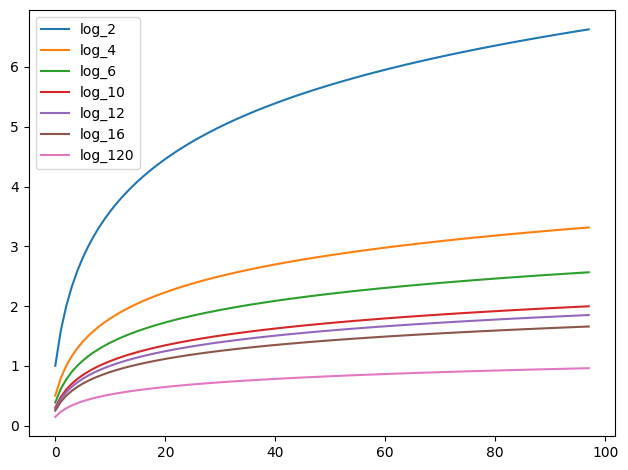

In [8]:
import numpy as np
from matplotlib import pyplot as plt
import math

series = np.array(range(2, 100))
bases = [2, 4, 6, 10, 12, 16, 120]

fig, ax = plt.subplots()
for b in bases:
    ax.plot([math.log(x, b) for x in series], label=f"log_{b}")
ax.legend()
plt.tight_layout()
plt.show()